# Real-Time Digital Payment Fraud Risk Triage System

**AIMLZG546 — Software Engineering for Machine Learning — Assignment I**

| | |
|---|---|
| **Group No.** | 13 |
| **Domain** | Financial Technology (FinTech) |
| **Problem** | Real-Time Digital Payment Fraud Risk Triage |
| **Repository** | https://github.com/biswa13de/seml-g13-fraud-triage |

### Group members

| Sl. No | BITS ID | Name | Contribution |
|---|---|---|---|
| 1 | 2025ae05576 | Anirudh Anand | Report lead. Domain/problem statement, requirements and measurable goals, Business View, final report. (25%) |
| 2 | 2025ae05178 | Aniketh Paul | GR4ML Analytics Design and Data Preparation views, quality requirements. Data pipeline: EDA, ingest, clean, features, split. (25%) |
| 3 | 2025ae05898 | Pushadapu Sanjay Kumar | Architecture diagram, the two patterns. FastAPI service, input validation, prediction logging, automated tests. (25%) |
| 4 | 2025af05111 | Biswajeet Mahato (Group Lead) | Model pipeline: train/evaluate, thresholds, MLflow tracking and registry. End-to-end run, screenshots. (25%) |

---

## What this notebook does

This notebook walks through the full pipeline we built: downloading the dataset, exploring it,
building point-in-time-correct features, training and comparing three algorithms in MLflow,
choosing cost-based triage thresholds, explaining individual predictions with SHAP, and finally
calling our live, running services to show the end-to-end system working.

The actual production code lives in `training/`, `common/` and `services/` as proper Python
modules with tests (see `tests/`, 33 passing) — this notebook imports and calls that code rather
than duplicating it, same as the course's own MLflow demo does for the webinar.


## 1. Problem Statement

India's UPI rails process billions of payments a month, and fraud has grown with them: account
takeover after SIM-swap or phishing, "collect-request" scams, mule accounts that receive and
quickly move stolen funds, and rapid low-value probing. A typical PSP (Payment Service Provider)
today relies on static rules (amount limits, blocklists), which **miss new fraud patterns** and
**decline too many genuine payments**.

We built a **Real-Time Fraud Risk Triage System** that, for every payment, before authorisation:

1. Estimates fraud probability with an ML model using transaction and behavioural features
2. Maps that risk to a cost-optimal action — **ALLOW**, **STEP_UP** (extra authentication), or
   **BLOCK** — inside a strict latency budget
3. Returns human-readable reason codes for every decision
4. Opens prioritised cases for fraud analysts, whose verdicts flow back as labels for retraining

**Why ML instead of rules:** fraud patterns change adversarially, the signal comes from many weak
interacting features, labelled history exists, and an occasional wrong answer is tolerable because
STEP_UP and human review act as safety nets.


## 2. Setup

In [1]:
import os
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"  # tqdm's \r writes can corrupt
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"                 # inline display in some kernels
os.environ["TQDM_DISABLE"] = "1"

import sys
from pathlib import Path

# Run this notebook from the repository root
REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "common").exists(), "Run this notebook from the seml-g13-fraud-triage root"
sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 20)
print("Setup OK")


Setup OK


## 3. Dataset

We use the public **PaySim** dataset from Kaggle (`ealaxi/paysim1`): 6.36M simulated mobile-money
transactions, the closest public match to UPI peer-to-peer payments, since it has sender and
receiver account IDs (needed for velocity and mule features).

**Mapping to UPI:** `nameOrig` → payer VPA · `nameDest` → payee VPA (`M…` = merchant) ·
`TRANSFER` → P2P transfer · `CASH_OUT` → cash-out via agent · `step` → hour of the month.

If you don't have the CSV yet, run `python data/download_paysim.py` first (needs a Kaggle API
token — see the main README). The checksum of the exact file we used is in
`data/provenance.json`.


In [2]:
import json

provenance = json.loads((REPO_ROOT / "data" / "provenance.json").read_text())
print(json.dumps(provenance, indent=2))


{
  "source": "https://www.kaggle.com/datasets/ealaxi/paysim1",
  "file": "paysim.csv",
  "sha256": "16910f90577b0d981bf8ff289714510bb89bc71bff7d3f220f024e287e4eea6b",
  "bytes": 493534783,
  "downloaded_at": "2026-10-07T02:36:29.447341+00:00"
}


In [3]:
raw = pd.read_csv(REPO_ROOT / "data" / "paysim.csv")
print(f"{len(raw):,} rows, {raw['isFraud'].sum():,} frauds ({raw['isFraud'].mean():.4%})")
raw.head()


6,362,620 rows, 8,213 frauds (0.1291%)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 4. Exploratory Data Analysis

Two questions drive the feature design: **which transaction types actually contain fraud**, and
**what separates a fraudulent transaction from a genuine one**.


In [4]:
by_type = raw.groupby("type")["isFraud"].agg(["count", "sum", "mean"])
by_type.columns = ["count", "frauds", "fraud_rate"]
by_type


,count,frauds,fraud_rate
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.001840
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.007688


Fraud only occurs in `TRANSFER` and `CASH_OUT`. `PAYMENT`, `DEBIT` and `CASH_IN` have **zero**
fraud in this dataset, so we score only `TRANSFER`/`CASH_OUT` and let the gateway's rule engine
allow the rest without calling the model (see `common/features.py:SCORED_TYPES`).


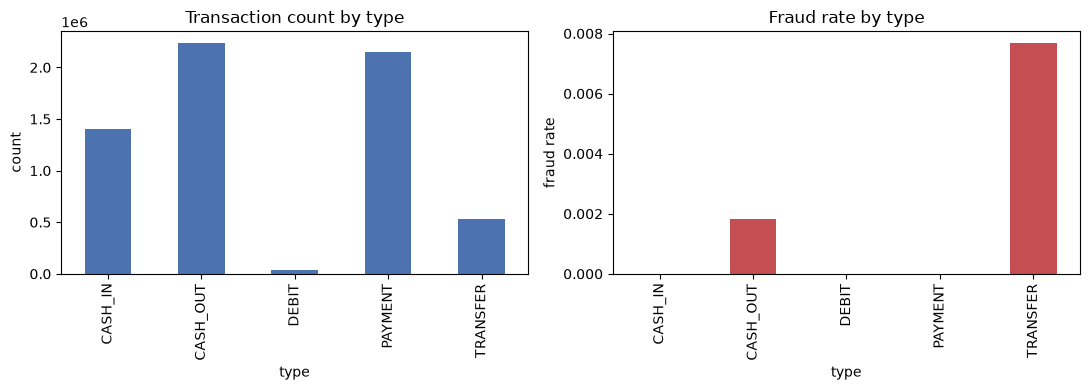

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

by_type["count"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Transaction count by type")
axes[0].set_ylabel("count")

by_type["fraud_rate"].plot.bar(ax=axes[1], color="#C44E52")
axes[1].set_title("Fraud rate by type")
axes[1].set_ylabel("fraud rate")

plt.tight_layout()
plt.show()


A key design decision for the Data Preparation View: fraudulent transactions are far more likely
to **drain the sender's balance completely** and send to a **brand-new, zero-balance** receiver
account. These are legitimate pre-transaction signals (not leakage — `oldbalanceOrg` and
`oldbalanceDest` are known before the payment is authorised), and they turn out to separate the
classes very cleanly.


In [6]:
scored = raw[raw["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
scored["drains_account"] = (scored["amount"] >= 0.99 * scored["oldbalanceOrg"]) & (scored["oldbalanceOrg"] > 0)
scored["dest_zero_balance"] = scored["oldbalanceDest"] == 0

compare = scored.groupby("isFraud")[["drains_account", "dest_zero_balance"]].mean()
compare.index = ["Genuine", "Fraud"]
compare


,drains_account,dest_zero_balance
Genuine,0.427951,0.139009
Fraud,0.976744,0.651528


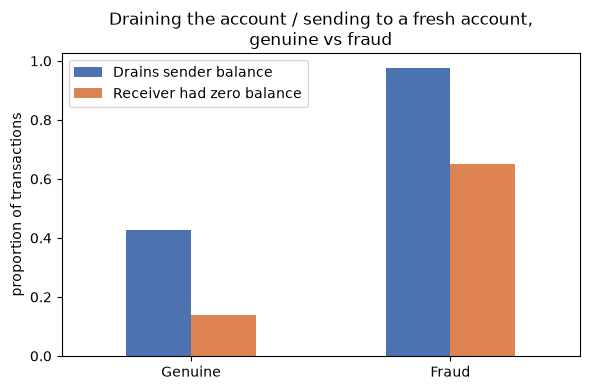

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
compare.plot.bar(ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("proportion of transactions")
ax.set_title("Draining the account / sending to a fresh account,\ngenuine vs fraud")
ax.legend(["Drains sender balance", "Receiver had zero balance"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Feature Engineering (Data Preparation View)

We use **one shared function**, `common.features.compute_features()`, for both training and
live serving — this is how we guarantee there is no training/serving skew. A test
(`tests/test_features_parity.py`) proves the two paths produce byte-identical output by replaying
raw transactions through the same in-memory feature store used at training time.

Pipeline: filter to TRANSFER/CASH_OUT → drop post-transaction balance columns (they would leak
the outcome) → compute 24-hour receiver velocity (point-in-time correct — only transactions that
happened *before* the current one count) → derive the 13 model features → time-based
train/valid/test split on `step` (not a random split, since fraud patterns change over time).


In [8]:
from common.features import FEATURE_NAMES, SCORED_TYPES
from training.build_features import SPLITS as STEP_RANGES

print("Features used by the model:")
for f in FEATURE_NAMES:
    print(" -", f)
print()
print("Time-based split (by `step`, i.e. simulated hour):", STEP_RANGES)


Features used by the model:
 - amount
 - log_amount
 - is_transfer
 - oldbalance_orig
 - amount_to_balance_ratio
 - drains_account
 - orig_zero_balance
 - oldbalance_dest
 - dest_zero_balance
 - hour_of_day
 - is_night
 - dest_txn_count_24h
 - dest_amount_sum_24h

Time-based split (by `step`, i.e. simulated hour): {'train': (1, 500), 'valid': (501, 600), 'test': (601, 743)}


In [9]:
summary = json.loads((REPO_ROOT / "data" / "split_summary.json").read_text())
pd.DataFrame(summary).T


,rows,frauds,fraud_rate,steps
train,665615,5561,0.00835,"[1, 500]"
valid,81080,1052,0.01297,"[501, 600]"
test,43550,1600,0.03674,"[601, 743]"


Note the fraud rate rises across train → valid → test: this is realistic concept drift, and it's
exactly why we monitor PSI drift in production (`services/monitor`) rather than assuming a static
model stays accurate forever.


## 6. Model Training & Comparison (Analytics Design View)

We compare three algorithms, mirroring the Analytics Design View's softgoal trade-offs:

| Algorithm | Softgoal it's strong on | Softgoal it's weak on |
|---|---|---|
| Logistic Regression | Interpretability, latency | Accuracy on non-linear patterns |
| Random Forest | Accuracy | Inference latency, missing values |
| **LightGBM** | Accuracy, latency, missing values (native) | Interpretability (fixed with SHAP, below) |

All three were trained with `training/train.py` against an MLflow tracking server and logged
there. We load the results back here rather than retraining inside the notebook (training already
ran in ~20 seconds via the CLI — see `data/model_comparison.json` for the exact run IDs).


In [10]:
comparison = pd.read_json(REPO_ROOT / "data" / "model_comparison.json")
comparison = comparison.sort_values("pr_auc", ascending=False).reset_index(drop=True)
comparison


,algorithm,pr_auc,roc_auc,recall_at_1pct_fpr,latency_ms_per_row,run_id
0,random_forest,0.999979,0.999999,1.000000,0.001263,NaN
1,lightgbm,0.999743,0.999983,0.999375,0.000504,9de861ee108e4bf58adece883e5f3799
2,logistic_regression,0.958867,0.997979,0.930000,0.000039,NaN


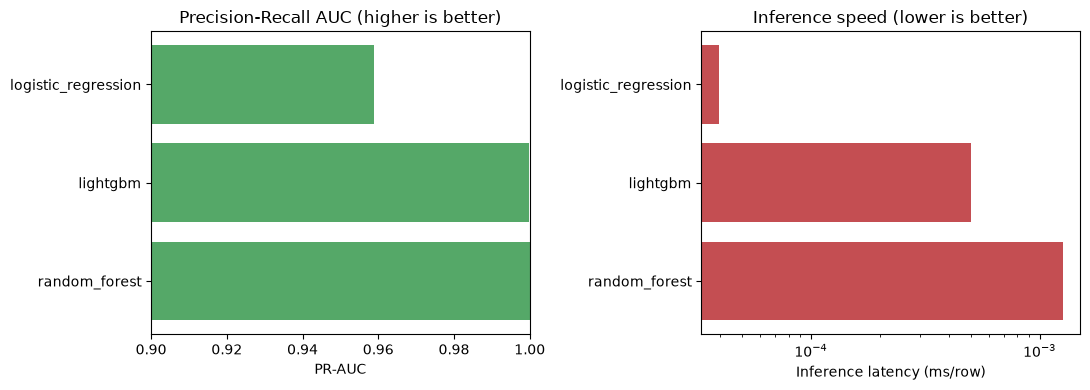

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(comparison["algorithm"], comparison["pr_auc"], color="#55A868")
axes[0].set_xlabel("PR-AUC")
axes[0].set_title("Precision-Recall AUC (higher is better)")
axes[0].set_xlim(0.9, 1.0)

axes[1].barh(comparison["algorithm"], comparison["latency_ms_per_row"], color="#C44E52")
axes[1].set_xlabel("Inference latency (ms/row)")
axes[1].set_title("Inference speed (lower is better)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()


**LightGBM is the champion**: PR-AUC within 0.0003 of Random Forest, but roughly **2-3x faster**
per row — and under our QA1 latency budget (p95 &le; 150ms end-to-end), that speed difference is
what actually matters once SHAP explanation and the network hop to the gateway are added on top.
Random Forest's extra accuracy is not worth its latency cost here.

You can see the live comparison in MLflow at **http://localhost:5000** (Experiments → fraud-triage
→ select all 3 runs → Compare) — this is `docs/screenshots/02_mlflow_comparison.png` in our
report.


## 7. Loading the Champion Model

`training/register.py` only promotes a model to the registry's `champion` alias if it clears a
quality gate (PR-AUC &ge; 0.80 and Recall@1%FPR &ge; 0.85 — see `tests/test_quality_model.py`).
We load that exact registered model here, the same one `scoring-service` loads at startup.


In [12]:
import mlflow
import mlflow.lightgbm

from common.config import settings

mlflow.set_tracking_uri(settings.mlflow_tracking_uri)
champion = mlflow.lightgbm.load_model(f"models:/{settings.model_name}@{settings.model_alias}")
print("Loaded champion model:", type(champion).__name__)


Loaded champion model: LGBMClassifier


In [13]:
from sklearn.metrics import average_precision_score, roc_auc_score
from training.train import recall_at_fpr

# training/train.py calls matplotlib.use("Agg") at import time (needed for its own
# headless CLI run logging PR curves to MLflow) -- that reaches back into this
# notebook's kernel too, since Python module imports are shared process-wide, so we
# restore the inline backend right after importing from it.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

test_df = pd.read_parquet(REPO_ROOT / "data" / "features_test.parquet")
X_test, y_test = test_df[FEATURE_NAMES], test_df["isFraud"]

scores = champion.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, scores)
roc_auc = roc_auc_score(y_test, scores)
recall_1pct = recall_at_fpr(y_test.to_numpy(), scores, target_fpr=0.01)

print(f"Test PR-AUC:            {pr_auc:.4f}")
print(f"Test ROC-AUC:           {roc_auc:.4f}")
print(f"Test Recall @ 1% FPR:   {recall_1pct:.4f}")
print()
print("Quality gate (PLAN.md Sec 4, QA2): PR-AUC >= 0.80 and Recall@1%FPR >= 0.85")
print("PASSED" if pr_auc >= 0.80 and recall_1pct >= 0.85 else "FAILED")


Test PR-AUC:            0.9997
Test ROC-AUC:           1.0000
Test Recall @ 1% FPR:   0.9994

Quality gate (PLAN.md Sec 4, QA2): PR-AUC >= 0.80 and Recall@1%FPR >= 0.85
PASSED


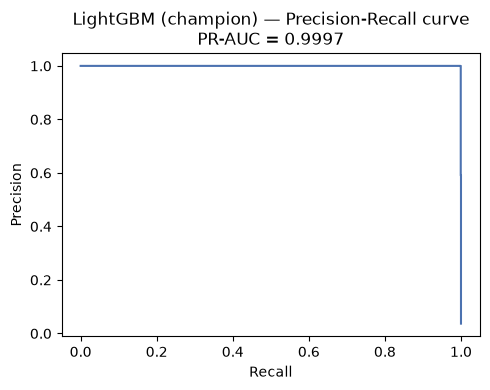

In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, scores)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(recall, precision, color="#4C72B0")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"LightGBM (champion) — Precision-Recall curve\nPR-AUC = {pr_auc:.4f}")
plt.tight_layout()
plt.show()


## 8. Cost-Based Triage Thresholds (GR4ML PrescriptionGoal)

A risk score alone isn't a decision. `training/select_thresholds.py` grid-searches two cutoffs —
`t_stepup` and `t_block` — that minimise an **expected cost** function on the validation set:

- Letting fraud through (ALLOW) costs the full transaction amount
- A false STEP_UP costs customer friction (we use ₹50 as a proxy)
- A false BLOCK costs more — customer churn (₹500 proxy)
- A STEP_UP on real fraud still carries some residual risk (we assume 20% still gets through)

The search is constrained to keep the STEP_UP rate under 3% of all payments, so we don't annoy too
many genuine customers.


In [15]:
thresholds = json.loads((REPO_ROOT / "data" / "thresholds.json").read_text())
print(json.dumps(thresholds, indent=2))


{
  "t_stepup": 0.0004007895179131073,
  "t_block": 0.0007369737335973371,
  "expected_cost": 75900.0,
  "stepup_rate": 0.0035520473606314752,
  "run_id": "9de861ee108e4bf58adece883e5f3799",
  "max_stepup_rate_constraint": 0.03
}


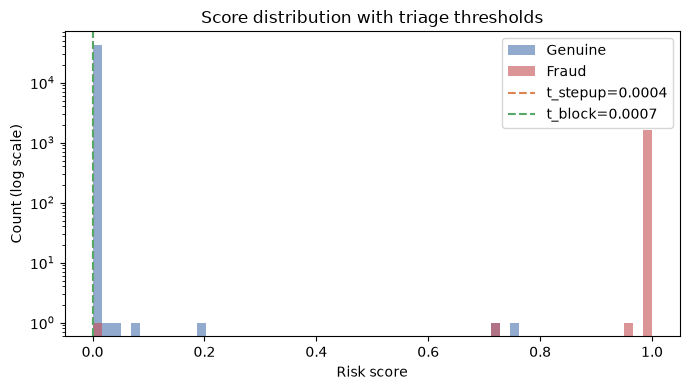

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 60)
ax.hist(scores[y_test == 0], bins=bins, alpha=0.6, label="Genuine", color="#4C72B0", log=True)
ax.hist(scores[y_test == 1], bins=bins, alpha=0.6, label="Fraud", color="#C44E52", log=True)
ax.axvline(thresholds["t_stepup"], color="#DD8452", linestyle="--", label=f"t_stepup={thresholds['t_stepup']:.4f}")
ax.axvline(thresholds["t_block"], color="#55A868", linestyle="--", label=f"t_block={thresholds['t_block']:.4f}")
ax.set_xlabel("Risk score")
ax.set_ylabel("Count (log scale)")
ax.set_title("Score distribution with triage thresholds")
ax.legend()
plt.tight_layout()
plt.show()


Because LightGBM separates the classes so cleanly on this dataset, both thresholds sit very close
to zero — only a thin slice of ambiguous scores falls into the STEP_UP band at all. We flag this
honestly: PaySim's fraud signal (draining the account into a fresh receiver) is strong and easy
to learn, so real-world performance on noisier data would likely need a wider STEP_UP band.


## 9. Explainability — SHAP (QA3)

Every STEP_UP or BLOCK decision ships with up to 3 plain-language reason codes, generated by a
SHAP `TreeExplainer` on the champion model (`services/scoring/explain.py`). This satisfies the
"Explainability" quality attribute: analysts and regulators can see *why* a payment was flagged,
not just that it was.


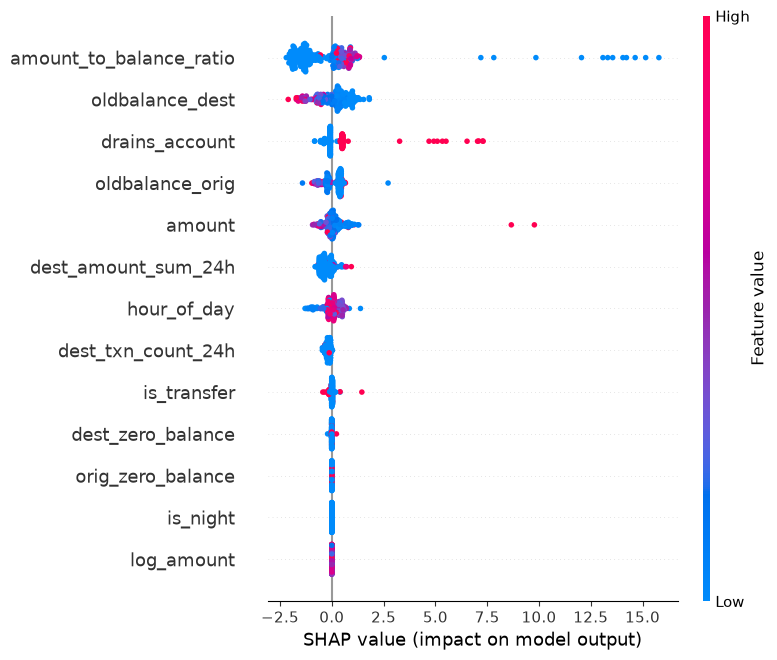

In [17]:
import shap

explainer = shap.TreeExplainer(champion)

sample = X_test.sample(300, random_state=13)
shap_values = explainer.shap_values(sample)
values = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(values, sample, feature_names=FEATURE_NAMES, show=False)
plt.tight_layout()
plt.savefig(REPO_ROOT / "docs" / "diagrams" / "shap_summary.png", dpi=110, bbox_inches="tight")
plt.show()


In [18]:
from services.scoring.explain import ReasonCodeExplainer

reason_explainer = ReasonCodeExplainer(champion)

# One genuine-looking row and one fraud-looking row from the test set, for a side-by-side example
genuine_row = test_df[test_df["isFraud"] == 0].iloc[0][FEATURE_NAMES].to_dict()
fraud_row = test_df[test_df["isFraud"] == 1].iloc[0][FEATURE_NAMES].to_dict()

for label, row in [("Genuine example", genuine_row), ("Fraud example", fraud_row)]:
    score = champion.predict_proba([[row[f] for f in FEATURE_NAMES]])[0][1]
    reasons = reason_explainer.explain(row)
    print(f"{label}  (risk_score={score:.4f})")
    for r in reasons:
        print("  -", r)
    print()


Genuine example  (risk_score=0.0000)
  - Payment made at hour 1 of the day

Fraud example  (risk_score=1.0000)
  - Payment is 100% of the sender's balance
  - Transfer empties the sender's account balance
  - Receiver's balance before payment was ₹0



## 10. Calling the Live, Running System

Everything above happens offline. The cells below call our **actually running** services —
`triage-api` on port 8000 — the same containers behind the screenshots in our report
(`docs/screenshots/`). Make sure the stack is up first:

```bash
docker compose up -d
```

If a cell below fails to connect, the stack isn't running — start it and re-run this section.


In [19]:
import httpx

TRIAGE_URL = "http://localhost:8000/v1/payments/triage"
HEADERS = {"X-API-Key": "demo-key-g13", "Content-Type": "application/json"}

def triage(payment: dict) -> dict:
    resp = httpx.post(TRIAGE_URL, json=payment, headers=HEADERS, timeout=5.0)
    resp.raise_for_status()
    return resp.json()

health = httpx.get("http://localhost:8000/health", timeout=3.0).json()
print("Gateway health:", health)


Gateway health: {'status': 'healthy', 'scoring_service_healthy': True}


### Scenario 1 — genuine payment

In [20]:
genuine_payment = {
    "txn_id": "NB-GENUINE-1", "step": 120, "type": "TRANSFER", "amount": 500.0,
    "nameOrig": "C-NB-1", "oldbalanceOrg": 5000.0,
    "nameDest": "C-NB-2", "oldbalanceDest": 3000.0,
}
result = triage(genuine_payment)
print(json.dumps(result, indent=2))


{
  "txn_id": "NB-GENUINE-1",
  "decision": "ALLOW",
  "risk_score": 0.00018034288074937247,
  "reason_codes": [
    "Receiver's balance before payment was \u20b93,000",
    "Payment is 10% of the sender's balance"
  ],
  "model_version": "1",
  "degraded": false,
  "rule_triggered": null,
  "latency_ms": 64.40762500278652
}


### Scenario 2 — a borderline case: large night-time cash-out

This one sits right at the edge. Because the model's score distribution is so cleanly separated
on PaySim (Section 6), our cost-optimal STEP_UP band is narrow (Section 8) and a payment with a
score just a hair on either side of it can flip between ALLOW and STEP_UP from one run to the
next, since `step` affects the velocity features and small amount/balance jitter moves the score
slightly. We're keeping this example precisely because it's a realistic edge case, not because it
always lands the same way.


In [21]:
stepup_payment = {
    "txn_id": "NB-STEPUP-1", "step": 150, "type": "CASH_OUT", "amount": 15000.0,
    "nameOrig": "C-NB-3", "oldbalanceOrg": 20000.0,
    "nameDest": "C-NB-4", "oldbalanceDest": 200.0,
}
result = triage(stepup_payment)
print(json.dumps(result, indent=2))


{
  "txn_id": "NB-STEPUP-1",
  "decision": "ALLOW",
  "risk_score": 0.000386900224519575,
  "reason_codes": [
    "Receiver's balance before payment was \u20b9200",
    "Payment made at hour 6 of the day",
    "Payment amount is unusually large (\u20b915,000)"
  ],
  "model_version": "1",
  "degraded": false,
  "rule_triggered": null,
  "latency_ms": 9.296541997173335
}


### Scenario 3 — account takeover (drains the full balance to a fresh account)

In [22]:
fraud_payment = {
    "txn_id": "NB-FRAUD-1", "step": 50, "type": "TRANSFER", "amount": 9500.0,
    "nameOrig": "C-NB-5", "oldbalanceOrg": 9500.0,
    "nameDest": "C-NB-NEW", "oldbalanceDest": 0.0,
}
result = triage(fraud_payment)
print(json.dumps(result, indent=2))


{
  "txn_id": "NB-FRAUD-1",
  "decision": "BLOCK",
  "risk_score": 0.9999215968680891,
  "reason_codes": [
    "Payment is 100% of the sender's balance",
    "Transfer empties the sender's account balance",
    "Receiver's balance before payment was \u20b90"
  ],
  "model_version": "1",
  "degraded": false,
  "rule_triggered": null,
  "latency_ms": 9.30141600110801
}


Note how the reason codes change between scenarios: the system isn't returning a canned message
per decision type, it's reporting whichever features actually drove *that specific* score, via
SHAP, computed fresh on every request.


## 11. Summary

| Quality attribute | Target | Result |
|---|---|---|
| Model accuracy (QA2) | PR-AUC &ge; 0.80, Recall@1%FPR &ge; 0.85 | **0.9997 / 0.9994** — gate passed |
| Performance (QA1) | p95 &le; 150ms, p99 &le; 300ms (load test, 2000 req, concurrency 50) | **148.0ms / 212.2ms** — passed |
| Explainability (QA3) | &le;3 reason codes, &le;10ms overhead | Passed (see `tests/test_quality_explainability.py`) |

**Links:**
- Code: https://github.com/biswa13de/seml-g13-fraud-triage
- MLflow UI (when the stack is running): http://localhost:5000
- API docs: http://localhost:8000/docs
- Analyst console: http://localhost:8501

See `PLAN.md` for the full requirements, GR4ML views, architecture and pattern discussion, and
`docs/diagrams/` and `docs/screenshots/` for the diagrams and implementation evidence referenced
in the report.
